# Observed Polar Amplification in the Historical Period

In [1]:
# mount google drive

#from google.colab import drive
#drive.mount('/content/drive')
#import sys
#sys.path.append('/content/drive/MyDrive/')

# load modules and packages

import xarray as xr
import matplotlib.pyplot as plt


In [2]:
# read NOAAGlobalTemp v6.0.0 (Huang et al. 2023)
# (https://www.ncei.noaa.gov/products/land-based-station/noaa-global-temp)
# (https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc%3AC01704/html)

ds = xr.open_dataset('NOAAGlobalTemp_v6.0.0.nc')


In [3]:
ds

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 2091, lat: 36, lon: 72, z: 1)
Coordinates:
  * time     (time) datetime64[ns] 17kB 1850-01-01 1850-02-01 ... 2024-03-01
  * lat      (lat) float32 144B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float32 288B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
  * z        (z) float32 4B 0.0
Data variables:
    anom     (time, z, lat, lon) float32 22MB ...
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA Merged Land Ocean Global Surface Te...
    summary:                         NOAAGlobalTemp is a merged land-ocean su...
    institution:                     DOC/NOAA/NESDIS/National Centers for Env...
    id:                               gov.noaa.ncdc:C00934 
    naming_authority:                 gov.noaa.ncei 
    ...                              ...
    time_coverage_duration:          P174Y3M
    references:                      Vose, R. S., et al., 2012: NOAAs merged ...
    climatology:                     Climatology is based on 1971-2000 monthl...
    acknowledgment:                  The NOAA Global Surface Temperature Data...
    date_modified:                   2024-04-08T19:27:01Z
    date_issued:                     2024-04-08T19:27:01Z

In [5]:
# calculate annual mean

dsym=ds.groupby('time.year').mean(dim='time')
dsym


<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 36, lon: 72, z: 1, year: 175)
Coordinates:
  * lat      (lat) float32 144B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float32 288B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
  * z        (z) float32 4B 0.0
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2021 2022 2023 2024
Data variables:
    anom     (year, z, lat, lon) float32 2MB -0.08197 -0.4426 ... 4.278 4.001
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA Merged Land Ocean Global Surface Te...
    summary:                         NOAAGlobalTemp is a merged land-ocean su...
    institution:                     DOC/NOAA/NESDIS/National Centers for Env...
    id:                               gov.noaa.ncdc:C00934 
    naming_authority:                 gov.noaa.ncei 
    ...                              ...
    time_coverage_duration:          P174Y3M
    references:                      Vose, R. S., et al., 2012: NOAAs merged ...
    climatology:                     Climatology is based on 1971-2000 monthl...
    acknowledgment:                  The NOAA Global Surface Temperature Data...
    date_modified:                   2024-04-08T19:27:01Z
    date_issued:                     2024-04-08T19:27:01Z

Note: Data for 2024 only contails 3 months and therefore should be excluded.

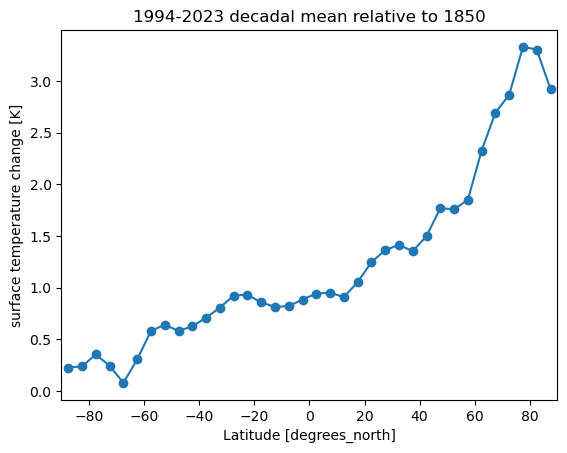

In [6]:
# select baseline and targeted time period

T0=dsym.anom.isel(year=slice(0,1)).mean(dim='year')
T=dsym.anom.isel(year=slice(-12,-2)).mean(dim='year')

(T-T0).mean(dim='lon').plot(marker='o')
plt.xlim([-90,90])
plt.ylabel('surface temperature change [K]')
plt.title('1994-2023 decadal mean relative to 1850')
plt.show()


Note: Computing the local linear trend would probably give more smoother spatial pattern.

In [8]:
import json
import openai
import os 

def load_api_key(secrets_file="/Users/kaichiht/openai.json"):
    with open(secrets_file) as f:
        secrets = json.load(f)
    return secrets["OPENAI_API_KEY"]

# Set secret API key
# Typically, we'd use an environment variable (e.g., echo "export OPENAI_API_KEY='yourkey'" >> ~/.zshrc)
# However, using "internalConsole" in launch.json requires setting it in the code for compatibility with Hebrew
api_key = load_api_key()
openai.api_key = api_key

%reload_ext jupyter_ai

os.environ["OPENAI_API_KEY"]=openai.api_key



UsageError: Line magic function `%%ai` not found.


In [10]:
%%ai chatgpt 

I have a data x(lat), which is a function of lat.  Can you provide a python code using Legendre polynomial to decompose the data?

```python
import numpy as np
from scipy.special import legendre
import matplotlib.pyplot as plt

# Generate synthetic data
lat = np.linspace(-90, 90, 100)
x = np.sin(lat*np.pi/180)

# Define the Legendre polynomial degree
degree = 5

# Compute Legendre polynomials
legendre_polynomials = np.zeros((degree+1, len(lat)))
for i in range(degree+1):
    legendre_polynomials[i,:] = legendre(i)(np.cos(lat*np.pi/180))

# Compute coefficients
coefficients = np.zeros(degree+1)
for i in range(degree+1):
    coefficients[i] = np.sum(x*legendre_polynomials[i,:]) / np.sum(legendre_polynomials[i,:]**2)

# Reconstruct the data
x_reconstructed = np.sum(coefficients[i]*legendre_polynomials[i,:] for i in range(degree+1))

# Plot original data and reconstructed data
plt.figure()
plt.plot(lat, x, label='Original Data')
plt.plot(lat, x_reconstructed, label='Reconstructed Data')
plt.legend()
plt.xlabel('Latitude')
plt.ylabel('Data x')
plt.title('Data Decomposition using Legendre Polynomials')
plt.show()
```

/var/folders/x1/nb2x5h5j08b2xx8xkc64r43m0000gn/T/ipykernel_7284/4091885872.py:23: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  x_reconstructed = np.sum(coefficients[i]*legendre_polynomials[i,:] for i in range(degree+1))


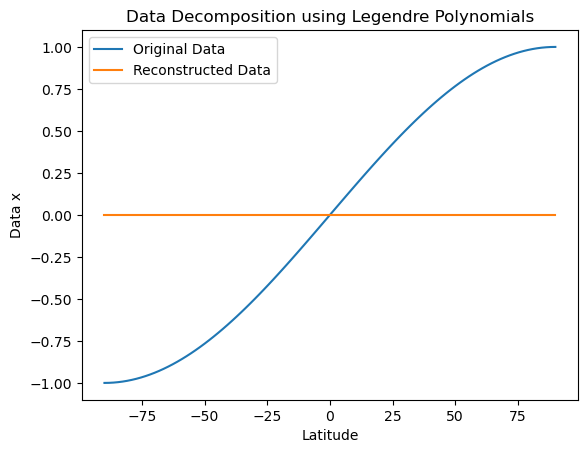

In [11]:
import numpy as np
from scipy.special import legendre
import matplotlib.pyplot as plt

# Generate synthetic data
lat = np.linspace(-90, 90, 100)
x = np.sin(lat*np.pi/180)

# Define the Legendre polynomial degree
degree = 5

# Compute Legendre polynomials
legendre_polynomials = np.zeros((degree+1, len(lat)))
for i in range(degree+1):
    legendre_polynomials[i,:] = legendre(i)(np.cos(lat*np.pi/180))

# Compute coefficients
coefficients = np.zeros(degree+1)
for i in range(degree+1):
    coefficients[i] = np.sum(x*legendre_polynomials[i,:]) / np.sum(legendre_polynomials[i,:]**2)

# Reconstruct the data
x_reconstructed = np.sum(coefficients[i]*legendre_polynomials[i,:] for i in range(degree+1))

# Plot original data and reconstructed data
plt.figure()
plt.plot(lat, x, label='Original Data')
plt.plot(lat, x_reconstructed, label='Reconstructed Data')
plt.legend()
plt.xlabel('Latitude')
plt.ylabel('Data x')
plt.title('Data Decomposition using Legendre Polynomials')
plt.show()

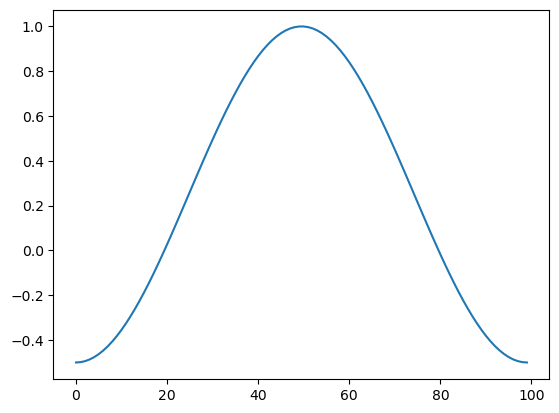

In [16]:
plt.plot(legendre_polynomials[2,:])